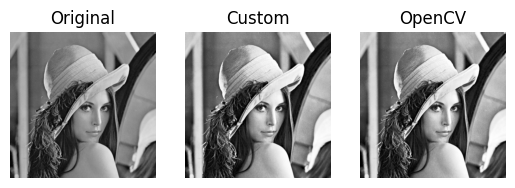

C:\Users\karth\AppData\Local\Temp\ipykernel_15876\2429380021.py:28: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.subplot(1,3,1); plt.hist(img.ravel(),256,[0,256]); plt.title("Original")
C:\Users\karth\AppData\Local\Temp\ipykernel_15876\2429380021.py:29: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.subplot(1,3,2); plt.hist(custom.ravel(),256,[0,256]); plt.title("Custom")
C:\Users\karth\AppData\Local\Temp\ipykernel_15876\2429380021.py:30: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.subplot(1,3,3); plt.hist(opencv_eq.ravel(),256,[0,256]); plt.title("OpenCV")


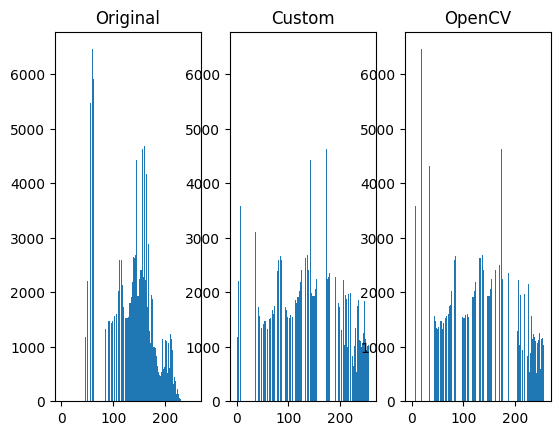

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Custom Histogram Equalization
def equalize_hist(img):
    levels, counts = np.unique(img, return_counts=True)
    pdf = counts / img.size
    cdf = np.cumsum(pdf)
    transform = np.floor(255 * cdf).astype(np.uint8)
    mapping = dict(zip(levels, transform))
    return np.vectorize(mapping.get)(img).astype(np.uint8)

# Read image
img = cv2.imread("example.jpg", 0)

# Apply equalization
custom = equalize_hist(img)
opencv_eq = cv2.equalizeHist(img)

# Display images
plt.subplot(1,3,1); plt.imshow(img, cmap='gray'); plt.title("Original"); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(custom, cmap='gray'); plt.title("Custom"); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(opencv_eq, cmap='gray'); plt.title("OpenCV"); plt.axis('off')
plt.show()

# Display histograms
plt.subplot(1,3,1); plt.hist(img.ravel(),256,[0,256]); plt.title("Original")
plt.subplot(1,3,2); plt.hist(custom.ravel(),256,[0,256]); plt.title("Custom")
plt.subplot(1,3,3); plt.hist(opencv_eq.ravel(),256,[0,256]); plt.title("OpenCV")
plt.show()